# Data Analysis on Uber Rides with Python

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Creating a dataframe from csv as df
df = pd.read_csv('UberDataset.csv')
# To check the top 5 rows
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [3]:
# To check the shape of the dataset
df.shape

(1156, 7)

In [4]:
# To check the information of the dataset - dtypes etc
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [5]:
# To check the statistics of the dataset
df.describe()

,MILES
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


In [6]:
# Date is in object, we need to change that to date time format
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce') # raises no error and marks it NaT
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors='coerce')

In [7]:
# To check the conversion
df['START_DATE'].dtype

dtype('<M8[ns]')

In [8]:
# To check any missing values
df.isnull().sum()

START_DATE      1
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [9]:
# To check the column: see how relevant it is, to drop it is hard since we have less than 1200 rows
df.PURPOSE

0        Meal/Entertain
1                   NaN
2       Errand/Supplies
3               Meeting
4        Customer Visit
             ...       
1151     Temporary Site
1152            Meeting
1153     Temporary Site
1154     Temporary Site
1155                NaN
Name: PURPOSE, Length: 1156, dtype: object

In [10]:
# We can see that some of the trips are not named, maybe the driver or app hasn't mentioned, we can name this as Unknown ride
df['PURPOSE'] = df['PURPOSE'].fillna("Unknown")
df['PURPOSE'].unique()

array(['Meal/Entertain', 'Unknown', 'Errand/Supplies', 'Meeting',
       'Customer Visit', 'Temporary Site', 'Between Offices',
       'Charity ($)', 'Commute', 'Moving', 'Airport/Travel'], dtype=object)

In [11]:
# Now we can drop the missing values since there is only one value missing in each cols
df = df.dropna()
# Let's check
df.isnull().sum()

START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
dtype: int64

In [12]:
# Let's take time from the data time for better visualization
df['TIME'] = df['START_DATE'].dt.strftime('%H.%M') # I am separating them with a dot for future use and not with ':'
df['TIME']

0       21.11
1       01.25
2       20.25
3       17.31
4       14.42
        ...  
1150    01.07
1151    13.24
1152    15.03
1153    21.32
1154    22.08
Name: TIME, Length: 1155, dtype: object

In [13]:
# Checking the dataframe
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,TIME
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.11
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,01.25
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20.25
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17.31
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14.42


In [14]:
# Since the time is in str format
df['TIME'] = df['TIME'].astype(float)
df['TIME'].dtype

dtype('float64')

In [15]:
# Let's create a function for making morning, afternoon, evening and night for visualization
def time_range(hour):
    if 5 <= hour < 12:
        return 'MORNING'
    elif 12 <= hour < 17:
        return 'AFTERNOON'
    elif 17 <= hour < 21:
        return 'EVENING'
    else:
        return 'NIGHT'

In [16]:
# Let's apply the function and see how this works
# I will create a new column for this called timeofday
df['TIME_OF_DAY'] = df['TIME'].apply(time_range)
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,TIME,TIME_OF_DAY
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.11,NIGHT
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,1.25,NIGHT
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20.25,EVENING
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17.31,EVENING
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14.42,AFTERNOON


In [17]:
# Let's check the individual trip time (in mins)
df['TRIP_TIME'] = (df['END_DATE'] - df['START_DATE']).dt.total_seconds() / 60
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,TIME,TIME_OF_DAY,TRIP_TIME
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.11,NIGHT,6.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,1.25,NIGHT,12.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20.25,EVENING,13.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17.31,EVENING,14.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14.42,AFTERNOON,67.0


In [18]:
# Let's see how many categories we have and check what are they!
print(df['CATEGORY'].nunique(), 'number(s) of unique categories')
print(df['CATEGORY'].unique(), 'are the of unique categories')

2 number(s) of unique categories
['Business' 'Personal'] are the of unique categories


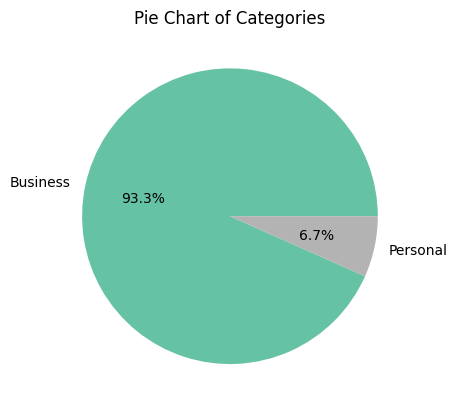

In [19]:
# Let's start visualization
df['CATEGORY'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Set2')
plt.ylabel('')
plt.title('Pie Chart of Categories')
plt.show()

### 93.3% the ride is made for business and rest for personal.

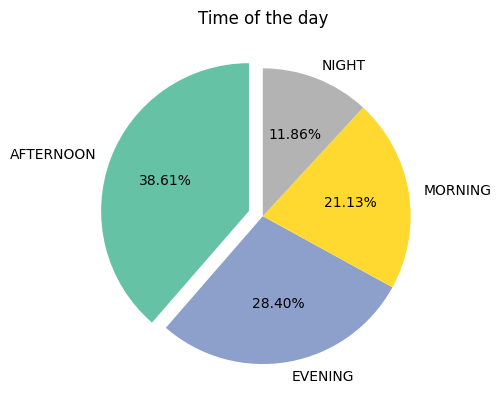

In [20]:
# To check the most driven time of the day
df['TIME_OF_DAY'].value_counts().plot(kind='pie', autopct='%1.2f%%', startangle=90, cmap='Set2', explode=[.1, 0, 0, 0])
plt.ylabel('')
plt.title('Time of the day')
plt.show()

### Based on the analysis, the highest number of rides are requested in the afternoon, followed by the evening and morning. However, night rides show a significant decline, indicating lower demand during late hours.

### This trend may suggest peak travel times align with work commutes, social activities, or other daytime engagements.

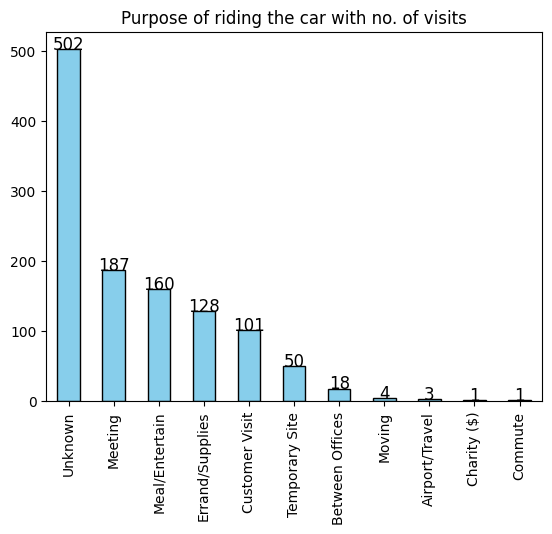

In [21]:
# Let's check the Purpose of riding in bar chart
ax = df['PURPOSE'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')

for i, v in enumerate(df['PURPOSE'].value_counts()):
    ax.text(i, v + 0.1, str(v), ha='center', fontsize=12)
plt.title("Purpose of riding the car with no. of visits")
plt.show()

### From the chart, we observe that the 'Unknown' ride category has the highest count, with 502 trips. This is followed by 'Meeting' with 187 trips and 'Meal/Entertainment' with 160 trips. The frequency gradually decreases, with 'Commute' recording the lowest count at just 1 trip.

In [22]:
# Total miles driven
df['MILES'].sum()

12204.7

#### Total number of miles driven for the year [2016] is 12204.7

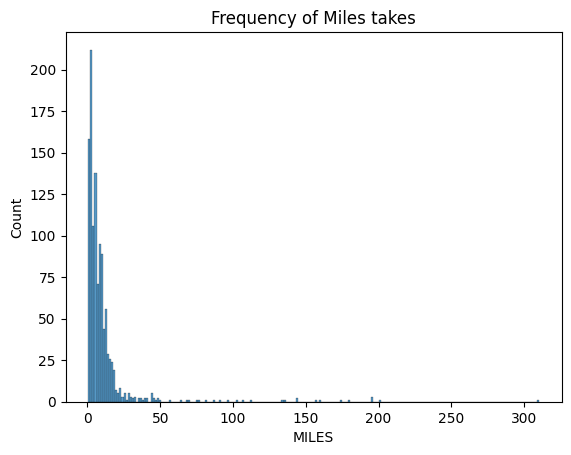

In [23]:
sns.histplot(df['MILES'])
plt.title('Frequency of Miles takes')
plt.show()

#### The chart represents the frequency of trips based on miles traveled. It is evident that short-distance trips (ranging from 1 to 25 miles) are the most common. Notably, a significant concentration of trips appears to occur within 10 miles, indicating a higher frequency of shorter rides.

#### This trend suggests that most rides are likely for daily commutes, local travel, or short-distance errands.

#### Below graphs would support the basic context of rides and relationship between miles, time and time of day.

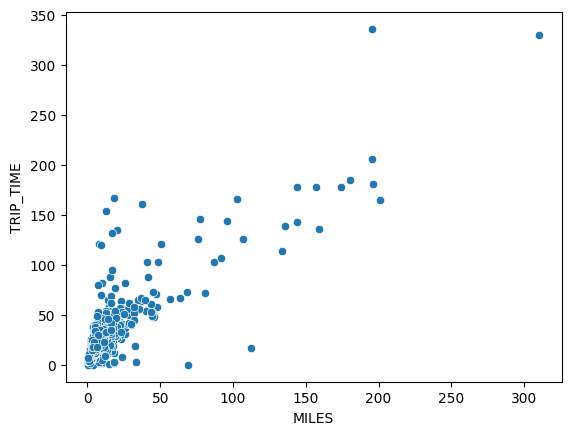

In [24]:
# Relation between miles and trip time
sns.scatterplot(x=df['MILES'], y=df['TRIP_TIME'])
plt.show()

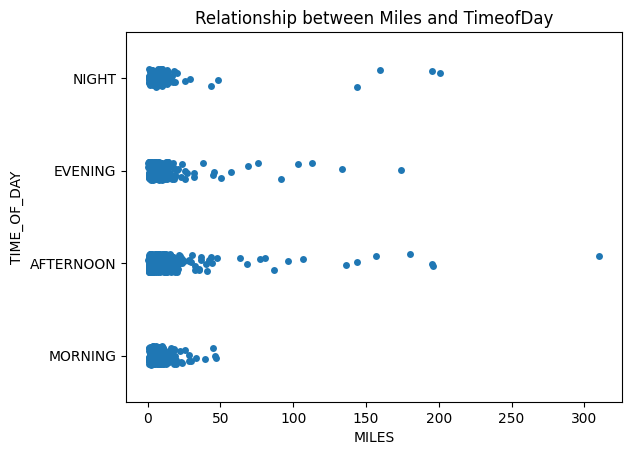

In [25]:
# Relationship between miles and timeofday
sns.stripplot(x=df['MILES'], y=df['TIME_OF_DAY'])
plt.title('Relationship between Miles and TimeofDay')
plt.show()

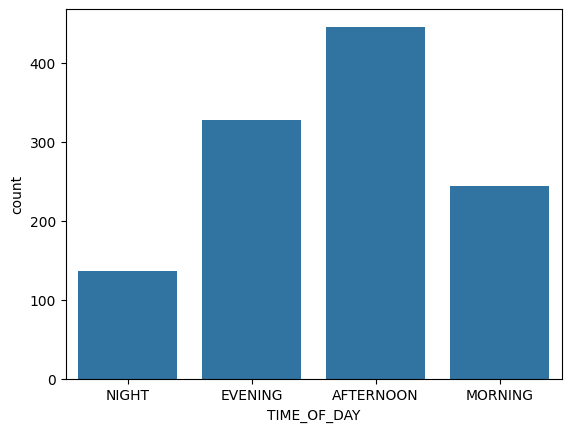

In [26]:
# As said in the above pie chart, the total occurances of afternoon rides are more, this is just to show how it looks with bar chart
sns.countplot(x=df['TIME_OF_DAY'])
plt.show()

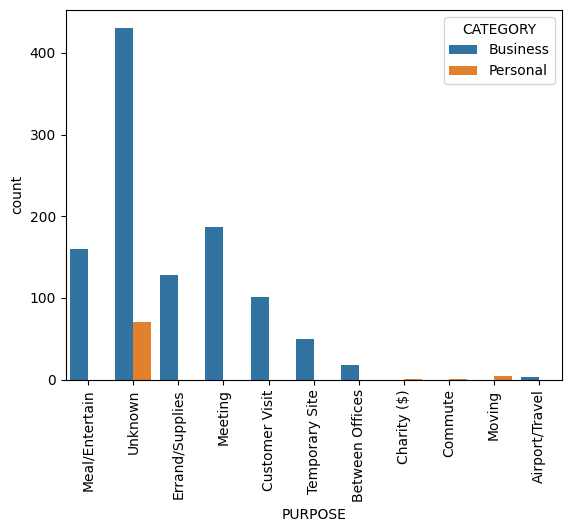

In [27]:
# Number of occurances for the categories like Business or Personal
sns.countplot(data=df, x='PURPOSE', hue='CATEGORY')
plt.xticks(rotation=90)
plt.show()

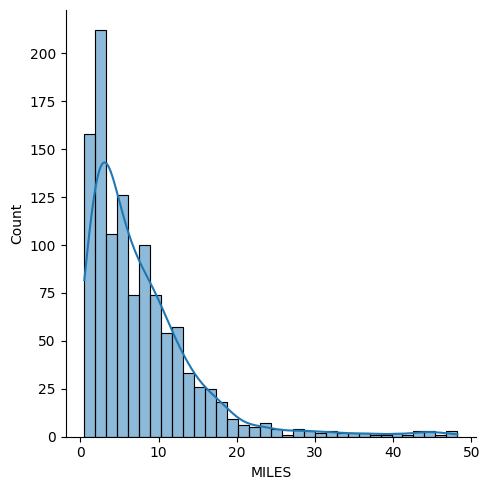

In [28]:
# Initial finding was I thought rides less than 10 miles is contributing more, to show that here we have distribution plot
sns.displot(df[df['MILES']<50]['MILES'], kde=True)
plt.show()

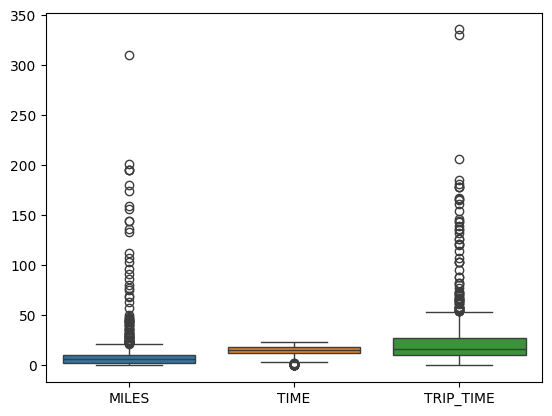

In [29]:
# To show the median, mean and how the miles, time and trip time contribute using box plot
sns.boxplot(df)
plt.show()